<a href="https://colab.research.google.com/github/lunecarvalho/newslens-project/blob/main/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("dataset_topics.csv")

print("Dimensões do dataset:", df.shape)

display(df.head())

print("\nColunas:")
print(df.columns.tolist())

print("\nInformações:")
df.info()

Dimensões do dataset: (7199, 7)


,id,label,arquivo,texto_original,texto_preprocessado,topico_bertopic,tema
0,1,falso,1170.txt,Falso médico é preso pela PM de Santa Catarina...,falso médico é preso pela pm de santa catarina...,28,Saúde
1,2,falso,1688.txt,Antes da confirmação da morte de Teori Zavasck...,antes da confirmação da morte de teori zavasck...,0,Política
2,3,falso,1863.txt,Senador que assume o lugar de Renan foi flagra...,senador que assume o lugar de renan foi flagra...,55,Política
3,4,falso,1563.txt,"Repórter relata conversa entre deputados: ""A D...",repórter relata conversa entre deputados: a di...,3,Corrupção
4,5,falso,3556.txt,Governo repressor e comunista usa exército par...,governo repressor e comunista usa exército par...,12,Política



Colunas:
['id', 'label', 'arquivo', 'texto_original', 'texto_preprocessado', 'topico_bertopic', 'tema']

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7199 entries, 0 to 7198
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7199 non-null   int64 
 1   label                7199 non-null   object
 2   arquivo              7199 non-null   object
 3   texto_original       7199 non-null   object
 4   texto_preprocessado  7199 non-null   object
 5   topico_bertopic      7199 non-null   int64 
 6   tema                 7199 non-null   object
dtypes: int64(2), object(5)
memory usage: 393.8+ KB


In [4]:
df.isnull().sum()

,0
id,0
label,0
arquivo,0
texto_original,0
texto_preprocessado,0
topico_bertopic,0
tema,0


In [3]:
print("Textos originais vazios:", df["texto_original"].isna().sum())
print("Textos pré-processados vazios:", df["texto_preprocessado"].isna().sum())
print("Temas vazios:", df["tema"].isna().sum())
print("Labels vazios:", df["label"].isna().sum())

Textos originais vazios: 0
Textos pré-processados vazios: 0
Temas vazios: 0
Labels vazios: 0


In [7]:
distribuicao_label = pd.DataFrame({
    "Quantidade": df["label"].value_counts(),
    "Porcentagem": df["label"].value_counts(normalize=True) * 100
})

display(distribuicao_label)

,Quantidade,Porcentagem
label,,
falso,3600,50.006945
verdadeiro,3599,49.993055


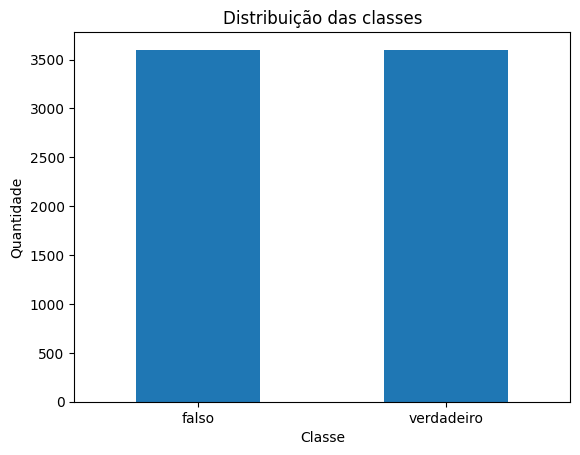

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [9]:
df["tema"].value_counts()

,count
tema,
Política,3285
Segurança,625
Corrupção,568
Internacional,530
Economia,404
Entretenimento,319
Saúde,233
Sociedade,206
Cultura,180


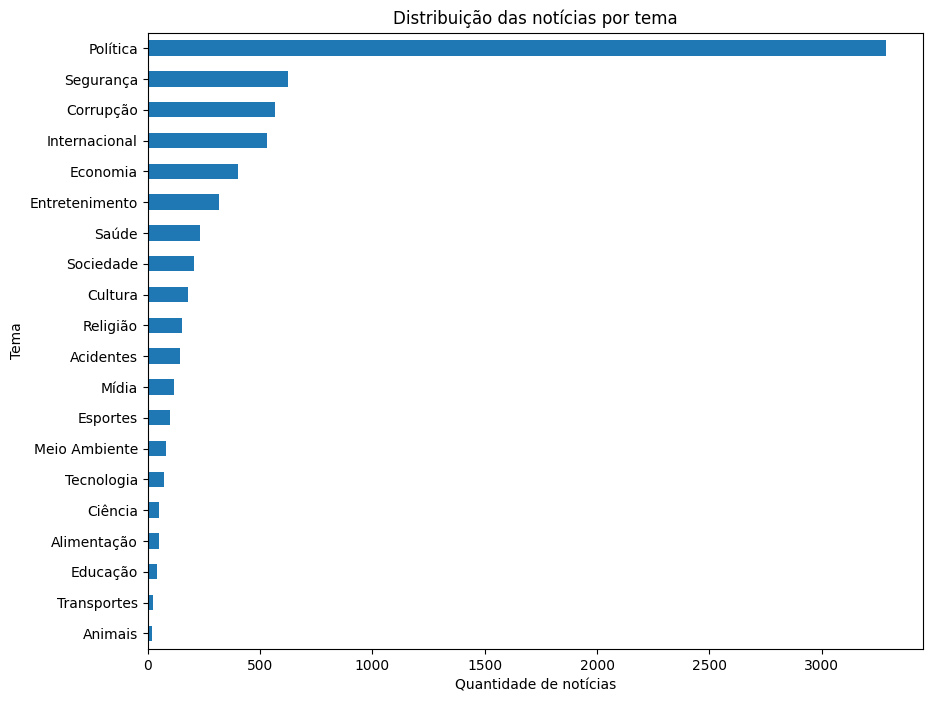

In [10]:
df["tema"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Distribuição das notícias por tema")
plt.xlabel("Quantidade de notícias")
plt.ylabel("Tema")
plt.show()

In [11]:
tema_label = pd.crosstab(
    df["tema"],
    df["label"]
)

display(tema_label)

label,falso,verdadeiro
tema,,
Acidentes,83,62
Alimentação,19,32
Animais,13,7
Ciência,28,23
Corrupção,299,269
Cultura,42,138
Economia,117,287
Educação,6,36
Entretenimento,199,120


In [12]:
tema_label_percentual = pd.crosstab(
    df["tema"],
    df["label"],
    normalize="index"
) * 100

display(tema_label_percentual.round(2))

label,falso,verdadeiro
tema,,
Acidentes,57.24,42.76
Alimentação,37.25,62.75
Animais,65.00,35.00
Ciência,54.90,45.10
Corrupção,52.64,47.36
Cultura,23.33,76.67
Economia,28.96,71.04
Educação,14.29,85.71
Entretenimento,62.38,37.62


In [13]:
df["tamanho_caracteres"] = df["texto_preprocessado"].str.len()

In [14]:
df["tamanho_palavras"] = df["texto_preprocessado"].str.split().str.len()

In [15]:
df[["tamanho_caracteres", "tamanho_palavras"]].describe()

,tamanho_caracteres,tamanho_palavras
count,7199.000000,7199.000000
mean,1103.320878,183.005695
std,697.240864,115.453693
min,46.000000,9.000000
25%,694.000000,115.000000
50%,946.000000,157.000000
75%,1340.000000,222.000000
max,12472.000000,2095.000000


In [16]:
df.groupby("label")[["tamanho_caracteres", "tamanho_palavras"]].mean()

,tamanho_caracteres,tamanho_palavras
label,,
falso,1090.721667,182.151389
verdadeiro,1115.923590,183.860239


In [26]:
df.groupby("label")[["tamanho_caracteres", "tamanho_palavras"]].median()

,tamanho_caracteres,tamanho_palavras
label,,
falso,939.0,156.0
verdadeiro,957.0,158.0


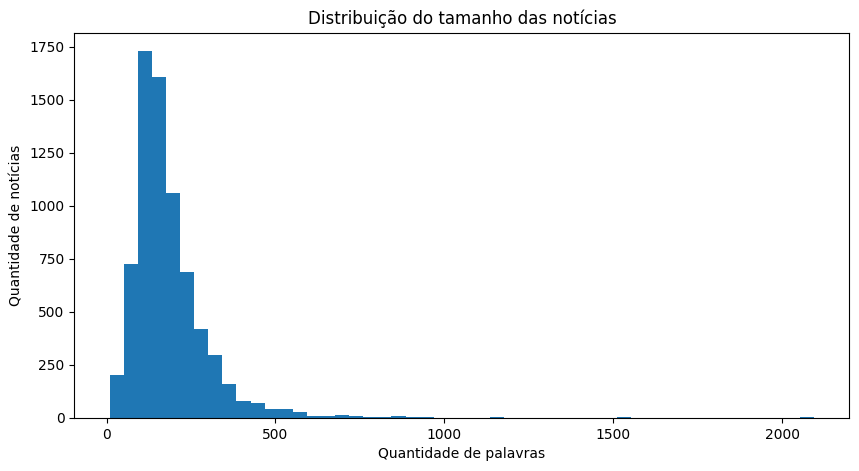

In [17]:
df["tamanho_palavras"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribuição do tamanho das notícias")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de notícias")
plt.show()

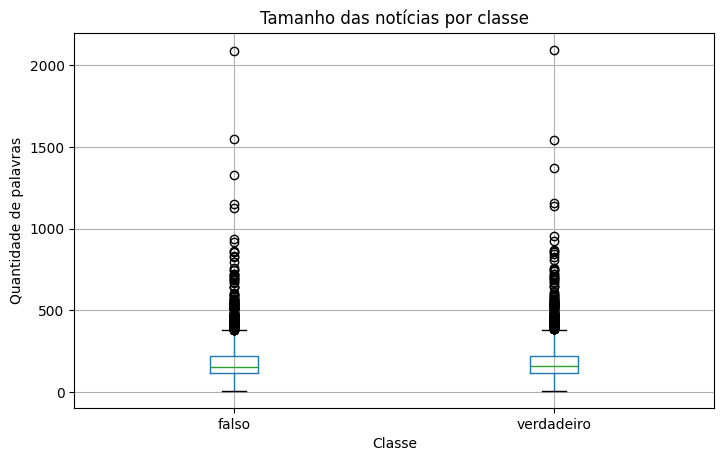

In [18]:
df.boxplot(
    column="tamanho_palavras",
    by="label",
    figsize=(8, 5)
)

plt.title("Tamanho das notícias por classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Quantidade de palavras")
plt.show()

In [19]:
from collections import Counter
import re

textos = " ".join(df["texto_preprocessado"].astype(str))

palavras = re.findall(r"\b[a-záàâãéêíóôõúç]+\b", textos.lower())

frequencia = Counter(palavras)

frequencia.most_common(20)

[('de', 61381),
 ('o', 44472),
 ('a', 41874),
 ('que', 34787),
 ('e', 31167),
 ('do', 28450),
 ('da', 24662),
 ('em', 19076),
 ('para', 14870),
 ('um', 12893),
 ('no', 12837),
 ('com', 11723),
 ('na', 11232),
 ('não', 10295),
 ('uma', 10201),
 ('é', 9626),
 ('os', 8639),
 ('se', 8158),
 ('por', 7317),
 ('foi', 6670)]

In [20]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stopwords_pt = set(stopwords.words("portuguese"))

palavras_filtradas = [
    palavra for palavra in palavras
    if palavra not in stopwords_pt
]

frequencia = Counter(palavras_filtradas)

frequencia.most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('presidente', 6482),
 ('lula', 4998),
 ('ex', 4704),
 ('disse', 3312),
 ('federal', 3293),
 ('anos', 2746),
 ('sobre', 2739),
 ('temer', 2739),
 ('feira', 2655),
 ('dilma', 2499),
 ('governo', 2475),
 ('brasil', 2375),
 ('ministro', 2292),
 ('r', 2188),
 ('país', 2163),
 ('diz', 2057),
 ('contra', 2041),
 ('jato', 2034),
 ('lava', 2026),
 ('ainda', 1871)]

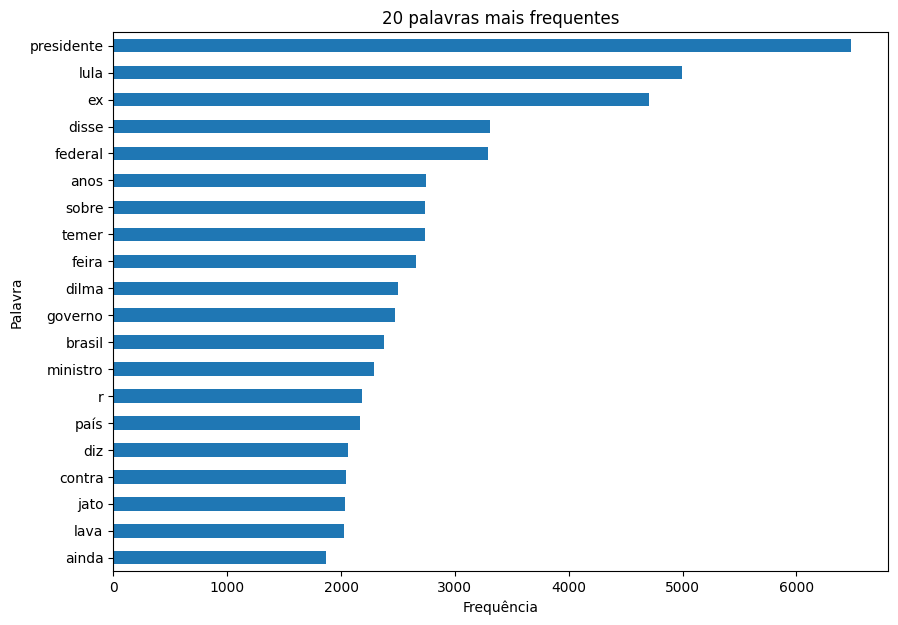

In [21]:
top_palavras = pd.DataFrame(
    frequencia.most_common(20),
    columns=["palavra", "frequencia"]
)

top_palavras = top_palavras.sort_values("frequencia")

top_palavras.plot(
    x="palavra",
    y="frequencia",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("20 palavras mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("Palavra")
plt.show()

In [22]:
textos_falsos = " ".join(
    df[df["label"] == "falso"]["texto_preprocessado"].astype(str)
)

textos_verdadeiros = " ".join(
    df[df["label"] == "verdadeiro"]["texto_preprocessado"].astype(str)
)

In [23]:
palavras_falsas = re.findall(
    r"\b[a-záàâãéêíóôõúç]+\b",
    textos_falsos.lower()
)

palavras_verdadeiras = re.findall(
    r"\b[a-záàâãéêíóôõúç]+\b",
    textos_verdadeiros.lower()
)

In [24]:
palavras_falsas = [
    p for p in palavras_falsas
    if p not in stopwords_pt
]

palavras_verdadeiras = [
    p for p in palavras_verdadeiras
    if p not in stopwords_pt
]

In [25]:
freq_falsas = Counter(palavras_falsas)
freq_verdadeiras = Counter(palavras_verdadeiras)

print("FALSAS:")
print(freq_falsas.most_common(20))

print("\nVERDADEIRAS:")
print(freq_verdadeiras.most_common(20))

FALSAS:
[('lula', 3041), ('presidente', 2960), ('disse', 2182), ('ex', 2029), ('dilma', 1867), ('brasil', 1396), ('país', 1225), ('governo', 1188), ('temer', 1163), ('federal', 1160), ('r', 1150), ('sobre', 1122), ('ministro', 1107), ('anos', 1078), ('ainda', 934), ('contra', 932), ('jato', 896), ('pt', 891), ('acordo', 888), ('lava', 885)]

VERDADEIRAS:
[('presidente', 3522), ('ex', 2675), ('feira', 2339), ('federal', 2133), ('lula', 1957), ('anos', 1668), ('sobre', 1617), ('temer', 1576), ('nesta', 1569), ('diz', 1297), ('governo', 1287), ('ministro', 1185), ('lava', 1141), ('jato', 1138), ('disse', 1130), ('contra', 1109), ('segundo', 1107), ('após', 1096), ('ano', 1050), ('dia', 1049)]


In [27]:
print("Exemplos com 'r':")
display(
    df[df["texto_preprocessado"].str.contains(r"\br\b", regex=True, na=False)]
    [["texto_original", "texto_preprocessado"]]
    .head(10)
)

print("\nExemplos com 'feira':")
display(
    df[df["texto_preprocessado"].str.contains(r"\bfeira\b", regex=True, na=False)]
    [["texto_original", "texto_preprocessado"]]
    .head(10)
)

Exemplos com 'r':


,texto_original,texto_preprocessado
15,Renan coloca urgência em projeto que autoriza ...,renan coloca urgência em projeto que autoriza ...
16,"Senadora que berrava ""é gópi ... é gópi "" dura...",senadora que berrava é gópi ... é gópi durante...
20,PF investiga ex-ministro petista suspeito de d...,pf investiga ex-ministro petista suspeito de d...
22,O sujo falando do mal lavado? Igreja Católica ...,o sujo falando do mal lavado? igreja católica ...
25,João Santana recebeu mais de R$ 55 milhões par...,joão santana recebeu mais de r 55 milhões para...
26,PROPINA 247: PF chega até blogueiro que mamava...,propina 247: pf chega até blogueiro que mamava...
39,Advogado citado na Lava-Jato morre em Brasília...,advogado citado na lava-jato morre em brasília...
40,Lula diz que vai processar lutador de MMA por ...,lula diz que vai processar lutador de mma por ...
56,Os dois ex-maridos de Dilma: Um era sequestrad...,os dois ex-maridos de dilma: um era sequestrad...
58,"""CLODOVIL foi assassinado porque queria diminu...",clodovil foi assassinado porque queria diminui...



Exemplos com 'feira':


,texto_original,texto_preprocessado
0,Falso médico é preso pela PM de Santa Catarina...,falso médico é preso pela pm de santa catarina...
2,Senador que assume o lugar de Renan foi flagra...,senador que assume o lugar de renan foi flagra...
3,"Repórter relata conversa entre deputados: ""A D...",repórter relata conversa entre deputados: a di...
7,"Jornalista diz que ""3 senadores do PT queriam ...",jornalista diz que 3 senadores do pt queriam q...
18,Cara de pau não tem limites: Zé Celso aciona M...,cara de pau não tem limites: zé celso aciona m...
24,A irresponsabilidade do governo federal. Aeron...,a irresponsabilidade do governo federal. aeron...
28,"No dia da corrida fatal, médico da F1 disse: ""...","no dia da corrida fatal, médico da f1 disse: d..."
48,Diretoria do Corinthians emite nota rejeitando...,diretoria do corinthians emite nota rejeitando...
62,"Em 2009, Barbosa alertou: ""Gilmar Mendes está ...","em 2009, barbosa alertou: gilmar mendes está d..."
64,"Após a condução coercitiva de Lula, juiz Moro ...","após a condução coercitiva de lula, juiz moro ..."


In [28]:
df[df["texto_preprocessado"].str.contains(
    r"\bsexta-feira\b|\bsegunda-feira\b|\bterça-feira\b|\bquarta-feira\b|\bquinta-feira\b|\bsábado\b|\bdomingo\b",
    case=False,
    regex=True,
    na=False
)][["texto_original", "texto_preprocessado"]].head(20)

,texto_original,texto_preprocessado
0,Falso médico é preso pela PM de Santa Catarina...,falso médico é preso pela pm de santa catarina...
2,Senador que assume o lugar de Renan foi flagra...,senador que assume o lugar de renan foi flagra...
3,"Repórter relata conversa entre deputados: ""A D...",repórter relata conversa entre deputados: a di...
7,"Jornalista diz que ""3 senadores do PT queriam ...",jornalista diz que 3 senadores do pt queriam q...
14,"""Avião com 500 kg de cocaína decolou de fazend...",avião com 500 kg de cocaína decolou de fazenda...
18,Cara de pau não tem limites: Zé Celso aciona M...,cara de pau não tem limites: zé celso aciona m...
24,A irresponsabilidade do governo federal. Aeron...,a irresponsabilidade do governo federal. aeron...
28,"No dia da corrida fatal, médico da F1 disse: ""...","no dia da corrida fatal, médico da f1 disse: d..."
47,Tchau querido! Defensor ferrenho de Dilma pode...,tchau querido! defensor ferrenho de dilma pode...
48,Diretoria do Corinthians emite nota rejeitando...,diretoria do corinthians emite nota rejeitando...


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
vectorizer = TfidfVectorizer(
    stop_words=list(stopwords_pt),
    ngram_range=(1, 1),
    min_df=2
)

In [31]:
X_tfidf = vectorizer.fit_transform(
    df["texto_preprocessado"]
)

In [32]:
print("Dimensões da matriz TF-IDF:", X_tfidf.shape)

Dimensões da matriz TF-IDF: (7199, 26255)


In [33]:
termos = vectorizer.get_feature_names_out()

print("Quantidade de termos:", len(termos))
print("\nPrimeiros 30 termos:")
print(termos[:30])

Quantidade de termos: 26255

Primeiros 30 termos:
['00' '000' '002' '007' '00h' '00hs' '01' '01022011' '016' '02' '020' '03'
 '03012017' '04' '042' '05' '06' '060' '065' '07' '070' '07950' '08' '09'
 '0h' '0h30' '10' '100' '1000' '10000']


In [34]:
import numpy as np

tfidf_medio = np.asarray(X_tfidf.mean(axis=0)).ravel()

termos_tfidf = pd.DataFrame({
    "termo": termos,
    "tfidf_medio": tfidf_medio
})

termos_tfidf = termos_tfidf.sort_values(
    "tfidf_medio",
    ascending=False
)

display(termos_tfidf.head(30))

,termo,tfidf_medio
15877,lula,0.028146
19986,presidente,0.025881
11003,ex,0.022226
24127,temer,0.017667
8851,dilma,0.016320
11636,federal,0.016202
9059,disse,0.014852
16793,ministro,0.013949
12846,governo,0.013253
11645,feira,0.013245


In [35]:
df_falsas = df[df["label"] == "falso"].copy()

X_falsas = vectorizer.transform(
    df_falsas["texto_preprocessado"]
)

tfidf_falsas = np.asarray(
    X_falsas.mean(axis=0)
).ravel()

termos_falsas = pd.DataFrame({
    "termo": termos,
    "tfidf_medio": tfidf_falsas
}).sort_values(
    "tfidf_medio",
    ascending=False
)

display(termos_falsas.head(30))

,termo,tfidf_medio
15877,lula,0.033894
8851,dilma,0.024502
19986,presidente,0.023209
9059,disse,0.019829
11003,ex,0.018529
24127,temer,0.015031
4118,brasil,0.014730
16793,ministro,0.013561
18799,país,0.013051
12846,governo,0.012753


In [36]:
df_verdadeiras = df[df["label"] == "verdadeiro"].copy()

X_verdadeiras = vectorizer.transform(
    df_verdadeiras["texto_preprocessado"]
)

tfidf_verdadeiras = np.asarray(
    X_verdadeiras.mean(axis=0)
).ravel()

termos_verdadeiras = pd.DataFrame({
    "termo": termos,
    "tfidf_medio": tfidf_verdadeiras
}).sort_values(
    "tfidf_medio",
    ascending=False
)

display(termos_verdadeiras.head(30))

,termo,tfidf_medio
19986,presidente,0.028554
11003,ex,0.025924
11645,feira,0.023658
15877,lula,0.022396
11636,federal,0.021263
24127,temer,0.020303
17526,nesta,0.019038
2101,anos,0.016388
23278,sobre,0.015544
16793,ministro,0.014338


In [37]:
comparacao_tfidf = pd.DataFrame({
    "termo": termos,
    "tfidf_falso": tfidf_falsas,
    "tfidf_verdadeiro": tfidf_verdadeiras
})

comparacao_tfidf["diferenca"] = (
    comparacao_tfidf["tfidf_falso"] -
    comparacao_tfidf["tfidf_verdadeiro"]
)

print("Termos mais associados às notícias falsas:")
display(
    comparacao_tfidf
    .sort_values("diferenca", ascending=False)
    .head(30)
)

print("Termos mais associados às notícias verdadeiras:")
display(
    comparacao_tfidf
    .sort_values("diferenca", ascending=True)
    .head(30)
)

Termos mais associados às notícias falsas:


,termo,tfidf_falso,tfidf_verdadeiro,diferenca
8851,dilma,0.024502,0.008136,0.016366
15877,lula,0.033894,0.022396,0.011498
9059,disse,0.019829,0.009873,0.009956
25972,vídeo,0.011921,0.003219,0.008702
12756,globo,0.008540,0.001805,0.006735
15048,jornalista,0.007924,0.001866,0.006058
13643,impeachment,0.008929,0.003269,0.005660
13253,hoje,0.010236,0.004646,0.005589
7055,coréia,0.005547,0.000069,0.005479
19759,pra,0.006520,0.001171,0.005349


Termos mais associados às notícias verdadeiras:


,termo,tfidf_falso,tfidf_verdadeiro,diferenca
11645,feira,0.002836,0.023658,-0.020822
17526,nesta,0.001581,0.019038,-0.017457
24812,tribunal,0.002763,0.013650,-0.010887
11636,federal,0.011143,0.021263,-0.010120
20804,quarta,0.001045,0.011049,-0.010003
278,2017,0.001182,0.010388,-0.009206
24260,terça,0.000794,0.009879,-0.009085
22835,segunda,0.002525,0.010754,-0.008229
20905,quinta,0.001206,0.009348,-0.008142
2092,ano,0.004639,0.012369,-0.007730


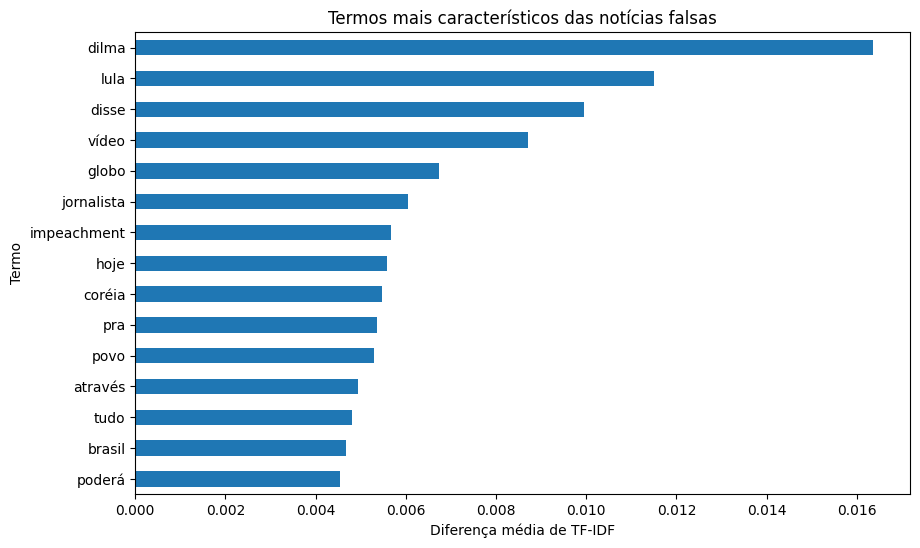

In [38]:
top_falsas = (
    comparacao_tfidf
    .sort_values("diferenca", ascending=False)
    .head(15)
    .sort_values("diferenca")
)

top_falsas.plot(
    x="termo",
    y="diferenca",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Termos mais característicos das notícias falsas")
plt.xlabel("Diferença média de TF-IDF")
plt.ylabel("Termo")
plt.show()

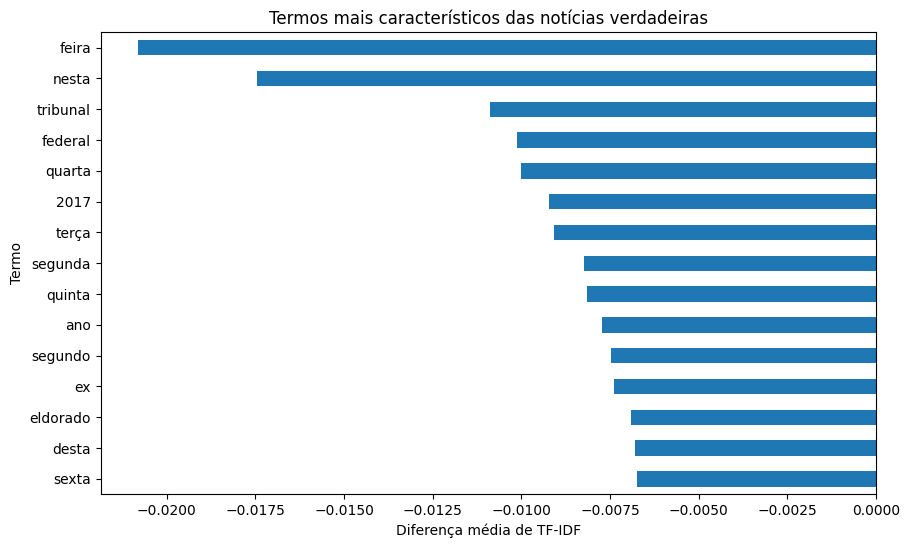

In [39]:
top_verdadeiras = (
    comparacao_tfidf
    .sort_values("diferenca", ascending=True)
    .head(15)
    .sort_values("diferenca", ascending=False)
)

top_verdadeiras.plot(
    x="termo",
    y="diferenca",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Termos mais característicos das notícias verdadeiras")
plt.xlabel("Diferença média de TF-IDF")
plt.ylabel("Termo")
plt.show()

In [40]:
vectorizer_bigramas = TfidfVectorizer(
    stop_words=list(stopwords_pt),
    ngram_range=(2, 2),
    min_df=2
)

X_bigramas = vectorizer_bigramas.fit_transform(
    df["texto_preprocessado"]
)

print("Dimensões da matriz TF-IDF de bigramas:", X_bigramas.shape)

Dimensões da matriz TF-IDF de bigramas: (7199, 70400)


In [42]:
indices_falsas = df["label"] == "falso"
indices_verdadeiras = df["label"] == "verdadeiro"

print("Notícias falsas:", indices_falsas.sum())
print("Notícias verdadeiras:", indices_verdadeiras.sum())

Notícias falsas: 3600
Notícias verdadeiras: 3599


In [45]:
# Converter os índices booleanos do pandas para arrays NumPy
indices_falsas_np = indices_falsas.to_numpy()
indices_verdadeiras_np = indices_verdadeiras.to_numpy()

# Média do TF-IDF dos bigramas em cada classe
tfidf_bigramas_falsas = X_bigramas[indices_falsas_np].mean(axis=0).A1
tfidf_bigramas_verdadeiras = X_bigramas[indices_verdadeiras_np].mean(axis=0).A1

# Obter os nomes dos bigramas
bigramas = vectorizer_bigramas.get_feature_names_out()

# Criar DataFrame para comparação
df_bigramas = pd.DataFrame({
    "bigrama": bigramas,
    "tfidf_falso": tfidf_bigramas_falsas,
    "tfidf_verdadeiro": tfidf_bigramas_verdadeiras
})

# Calcular a diferença
df_bigramas["diferenca"] = (
    df_bigramas["tfidf_falso"] -
    df_bigramas["tfidf_verdadeiro"]
)

df_bigramas.head()

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
0,00 43,0.000028,0.0,0.000028
1,00 absolutamente,0.000028,0.0,0.000028
2,00 cem,0.000072,0.0,0.000072
3,00 cirque,0.000082,0.0,0.000082
4,00 horas,0.000110,0.0,0.000110


In [46]:
top_bigramas_falsos = (
    df_bigramas
    .sort_values("diferenca", ascending=False)
    .head(30)
)

top_bigramas_falsos

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
16422,coréia norte,0.005568,0.000078,0.005490
57367,redes sociais,0.008452,0.003181,0.005271
22807,diário brasil,0.003383,0.000000,0.003383
69679,vídeo abaixo,0.003223,0.000176,0.003047
63765,sérgio moro,0.008370,0.005476,0.002893
23796,eduardo cunha,0.005531,0.002799,0.002733
61176,sergio moro,0.003274,0.000626,0.002647
57346,rede globo,0.002712,0.000130,0.002582
39216,manhã hoje,0.002498,0.000078,0.002420
21025,dilma rousseff,0.006788,0.004391,0.002397


In [47]:
top_bigramas_verdadeiros = (
    df_bigramas
    .sort_values("diferenca", ascending=True)
    .head(30)
)

top_bigramas_verdadeiros

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
56149,quarta feira,0.001017,0.010105,-0.009088
65188,terça feira,0.000878,0.008972,-0.008094
56586,quinta feira,0.001212,0.008705,-0.007493
43662,nesta quarta,0.000283,0.007381,-0.007098
60199,segunda feira,0.001303,0.008255,-0.006952
43671,nesta terça,0.000286,0.006860,-0.006574
61417,sexta feira,0.001501,0.008004,-0.006503
66491,tribunal federal,0.001896,0.007890,-0.005995
16134,coreia norte,0.003287,0.009224,-0.005937
63549,supremo tribunal,0.001978,0.007905,-0.005926


In [48]:
import unicodedata

def remover_acentos(texto):
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(
        caractere
        for caractere in texto
        if unicodedata.category(caractere) != "Mn"
    )
    return texto

df["texto_preprocessado_sem_acento"] = (
    df["texto_preprocessado"]
    .apply(remover_acentos)
)

df[["texto_preprocessado", "texto_preprocessado_sem_acento"]].head()

,texto_preprocessado,texto_preprocessado_sem_acento
0,falso médico é preso pela pm de santa catarina...,falso medico e preso pela pm de santa catarina...
1,antes da confirmação da morte de teori zavasck...,antes da confirmacao da morte de teori zavasck...
2,senador que assume o lugar de renan foi flagra...,senador que assume o lugar de renan foi flagra...
3,repórter relata conversa entre deputados: a di...,reporter relata conversa entre deputados: a di...
4,governo repressor e comunista usa exército par...,governo repressor e comunista usa exercito par...


In [49]:
vectorizer_bigramas_normalizado = TfidfVectorizer(
    stop_words=list(stopwords_pt),
    ngram_range=(2, 2),
    min_df=2
)

X_bigramas_normalizado = vectorizer_bigramas_normalizado.fit_transform(
    df["texto_preprocessado_sem_acento"]
)

print(
    "Dimensões da matriz TF-IDF de bigramas normalizada:",
    X_bigramas_normalizado.shape
)

Dimensões da matriz TF-IDF de bigramas normalizada: (7199, 75068)


In [50]:
# Índices das notícias falsas e verdadeiras
indices_falsas_np = (df["label"] == "falso").to_numpy()
indices_verdadeiras_np = (df["label"] == "verdadeiro").to_numpy()

# Média do TF-IDF dos bigramas em cada classe
tfidf_bigramas_falsas_norm = (
    X_bigramas_normalizado[indices_falsas_np]
    .mean(axis=0)
    .A1
)

tfidf_bigramas_verdadeiras_norm = (
    X_bigramas_normalizado[indices_verdadeiras_np]
    .mean(axis=0)
    .A1
)

# Nomes dos bigramas
bigramas_normalizados = (
    vectorizer_bigramas_normalizado
    .get_feature_names_out()
)

# Criar tabela
df_bigramas_normalizado = pd.DataFrame({
    "bigrama": bigramas_normalizados,
    "tfidf_falso": tfidf_bigramas_falsas_norm,
    "tfidf_verdadeiro": tfidf_bigramas_verdadeiras_norm
})

# Diferença entre falso e verdadeiro
df_bigramas_normalizado["diferenca"] = (
    df_bigramas_normalizado["tfidf_falso"]
    - df_bigramas_normalizado["tfidf_verdadeiro"]
)

df_bigramas_normalizado.head()

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
0,00 43,0.000027,0.0,0.000027
1,00 absolutamente,0.000027,0.0,0.000027
2,00 ate,0.000097,0.0,0.000097
3,00 audio,0.000093,0.0,0.000093
4,00 cem,0.000071,0.0,0.000071


In [51]:
top_bigramas_falsos_norm = (
    df_bigramas_normalizado
    .sort_values("diferenca", ascending=False)
    .head(30)
)

top_bigramas_falsos_norm

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
60971,redes sociais,0.007975,0.003050,0.004925
38933,leia tambem,0.004771,0.000156,0.004615
65433,sergio moro,0.009873,0.005592,0.004281
21445,diario brasil,0.003218,0.000000,0.003218
73904,video abaixo,0.003084,0.000174,0.002910
24523,eduardo cunha,0.005320,0.002749,0.002571
60949,rede globo,0.002550,0.000123,0.002427
41186,manha hoje,0.002406,0.000077,0.002329
21998,dinheiro publico,0.002754,0.000544,0.002210
21827,dilma rousseff,0.006481,0.004305,0.002177


In [52]:
top_bigramas_verdadeiros_norm = (
    df_bigramas_normalizado
    .sort_values("diferenca", ascending=True)
    .head(30)
)

top_bigramas_verdadeiros_norm

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
59712,quarta feira,0.000982,0.009887,-0.008905
69916,terca feira,0.000853,0.008721,-0.007868
60161,quinta feira,0.001158,0.008485,-0.007327
46943,nesta quarta,0.000272,0.007231,-0.006959
64206,segunda feira,0.001249,0.008057,-0.006808
46952,nesta terca,0.000279,0.006695,-0.006416
65727,sexta feira,0.001439,0.007792,-0.006353
71454,tribunal federal,0.001819,0.007726,-0.005907
68094,supremo tribunal,0.001898,0.007740,-0.005842
46944,nesta quinta,0.000380,0.005945,-0.005565


In [53]:
# 15 bigramas mais associados às notícias falsas
top15_falsos = (
    df_bigramas_normalizado
    .sort_values("diferenca", ascending=False)
    .head(15)
    .copy()
)

# 15 bigramas mais associados às notícias verdadeiras
top15_verdadeiros = (
    df_bigramas_normalizado
    .sort_values("diferenca", ascending=True)
    .head(15)
    .copy()
)

print("Top 15 — Notícias falsas")
display(top15_falsos)

print("\nTop 15 — Notícias verdadeiras")
display(top15_verdadeiros)

Top 15 — Notícias falsas


,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
60971,redes sociais,0.007975,0.003050,0.004925
38933,leia tambem,0.004771,0.000156,0.004615
65433,sergio moro,0.009873,0.005592,0.004281
21445,diario brasil,0.003218,0.000000,0.003218
73904,video abaixo,0.003084,0.000174,0.002910
24523,eduardo cunha,0.005320,0.002749,0.002571
60949,rede globo,0.002550,0.000123,0.002427
41186,manha hoje,0.002406,0.000077,0.002329
21998,dinheiro publico,0.002754,0.000544,0.002210
21827,dilma rousseff,0.006481,0.004305,0.002177



Top 15 — Notícias verdadeiras


,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca
59712,quarta feira,0.000982,0.009887,-0.008905
69916,terca feira,0.000853,0.008721,-0.007868
60161,quinta feira,0.001158,0.008485,-0.007327
46943,nesta quarta,0.000272,0.007231,-0.006959
64206,segunda feira,0.001249,0.008057,-0.006808
46952,nesta terca,0.000279,0.006695,-0.006416
65727,sexta feira,0.001439,0.007792,-0.006353
71454,tribunal federal,0.001819,0.007726,-0.005907
68094,supremo tribunal,0.001898,0.007740,-0.005842
46944,nesta quinta,0.000380,0.005945,-0.005565


In [54]:
falsos_interpretacao = top15_falsos.copy()
verdadeiros_interpretacao = top15_verdadeiros.copy()

categorias_falsos = {
    "redes sociais": "Mídia e redes sociais",
    "leia tambem": "Linguagem editorial",
    "sergio moro": "Política",
    "diario brasil": "Mídia e redes sociais",
    "video abaixo": "Linguagem editorial",
    "eduardo cunha": "Política",
    "rede globo": "Mídia e redes sociais",
    "manha hoje": "Temporal",
    "dinheiro publico": "Economia/gestão pública",
    "dilma rousseff": "Política",
    "ultimo dia": "Temporal",
    "globo news": "Mídia e redes sociais",
    "povo brasileiro": "Política/sociedade",
    "dilma nao": "Política",
    "kim jon": "Política/internacional"
}

categorias_verdadeiros = {
    "quarta feira": "Temporal",
    "terca feira": "Temporal",
    "quinta feira": "Temporal",
    "nesta quarta": "Temporal",
    "segunda feira": "Temporal",
    "nesta terca": "Temporal",
    "sexta feira": "Temporal",
    "tribunal federal": "Institucional",
    "supremo tribunal": "Institucional",
    "nesta quinta": "Temporal",
    "inacio lula": "Política",
    "nesta segunda": "Temporal",
    "presidente luiz": "Política",
    "federal stf": "Institucional",
    "sao paulo": "Geográfico"
}

# Adicionar categorias
falsos_interpretacao["classe"] = "Falsa"
falsos_interpretacao["categoria"] = (
    falsos_interpretacao["bigrama"].map(categorias_falsos)
)

verdadeiros_interpretacao["classe"] = "Verdadeira"
verdadeiros_interpretacao["categoria"] = (
    verdadeiros_interpretacao["bigrama"].map(categorias_verdadeiros)
)

# Juntar os dois conjuntos
df_bigramas_interpretacao = pd.concat(
    [falsos_interpretacao, verdadeiros_interpretacao],
    ignore_index=True
)

# Organizar as colunas
df_bigramas_interpretacao = df_bigramas_interpretacao[
    [
        "bigrama",
        "tfidf_falso",
        "tfidf_verdadeiro",
        "diferenca",
        "classe",
        "categoria"
    ]
]

df_bigramas_interpretacao

,bigrama,tfidf_falso,tfidf_verdadeiro,diferenca,classe,categoria
0,redes sociais,0.007975,0.003050,0.004925,Falsa,Mídia e redes sociais
1,leia tambem,0.004771,0.000156,0.004615,Falsa,Linguagem editorial
2,sergio moro,0.009873,0.005592,0.004281,Falsa,Política
3,diario brasil,0.003218,0.000000,0.003218,Falsa,Mídia e redes sociais
4,video abaixo,0.003084,0.000174,0.002910,Falsa,Linguagem editorial
5,eduardo cunha,0.005320,0.002749,0.002571,Falsa,Política
6,rede globo,0.002550,0.000123,0.002427,Falsa,Mídia e redes sociais
7,manha hoje,0.002406,0.000077,0.002329,Falsa,Temporal
8,dinheiro publico,0.002754,0.000544,0.002210,Falsa,Economia/gestão pública
9,dilma rousseff,0.006481,0.004305,0.002177,Falsa,Política


In [55]:
contagem_categorias = (
    df_bigramas_interpretacao
    .groupby(["classe", "categoria"])
    .size()
    .reset_index(name="quantidade")
)

contagem_categorias

,classe,categoria,quantidade
0,Falsa,Economia/gestão pública,1
1,Falsa,Linguagem editorial,2
2,Falsa,Mídia e redes sociais,4
3,Falsa,Política,4
4,Falsa,Política/internacional,1
5,Falsa,Política/sociedade,1
6,Falsa,Temporal,2
7,Verdadeira,Geográfico,1
8,Verdadeira,Institucional,3
9,Verdadeira,Política,2


In [56]:
tabela_categorias = pd.crosstab(
    df_bigramas_interpretacao["categoria"],
    df_bigramas_interpretacao["classe"]
)

tabela_categorias

classe,Falsa,Verdadeira
categoria,,
Economia/gestão pública,1,0
Geográfico,0,1
Institucional,0,3
Linguagem editorial,2,0
Mídia e redes sociais,4,0
Política,4,2
Política/internacional,1,0
Política/sociedade,1,0
Temporal,2,9


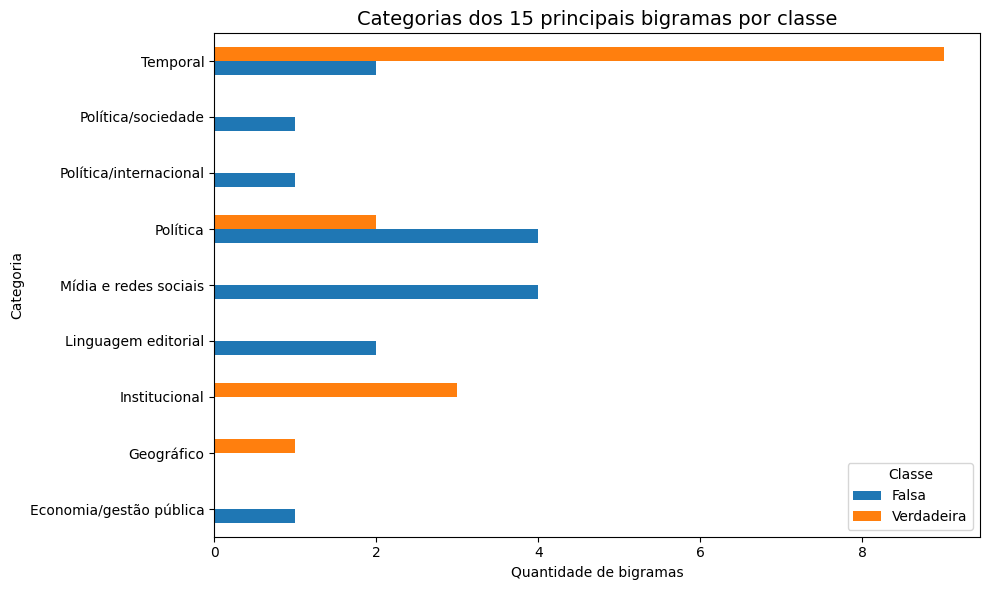

In [57]:
import matplotlib.pyplot as plt

dados_grafico = tabela_categorias.copy()

# Criar gráfico
ax = dados_grafico.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Categorias dos 15 principais bigramas por classe",
    fontsize=14
)

plt.xlabel("Quantidade de bigramas")
plt.ylabel("Categoria")

plt.legend(
    title="Classe"
)

plt.tight_layout()
plt.show()

In [58]:
!pip install wordcloud

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

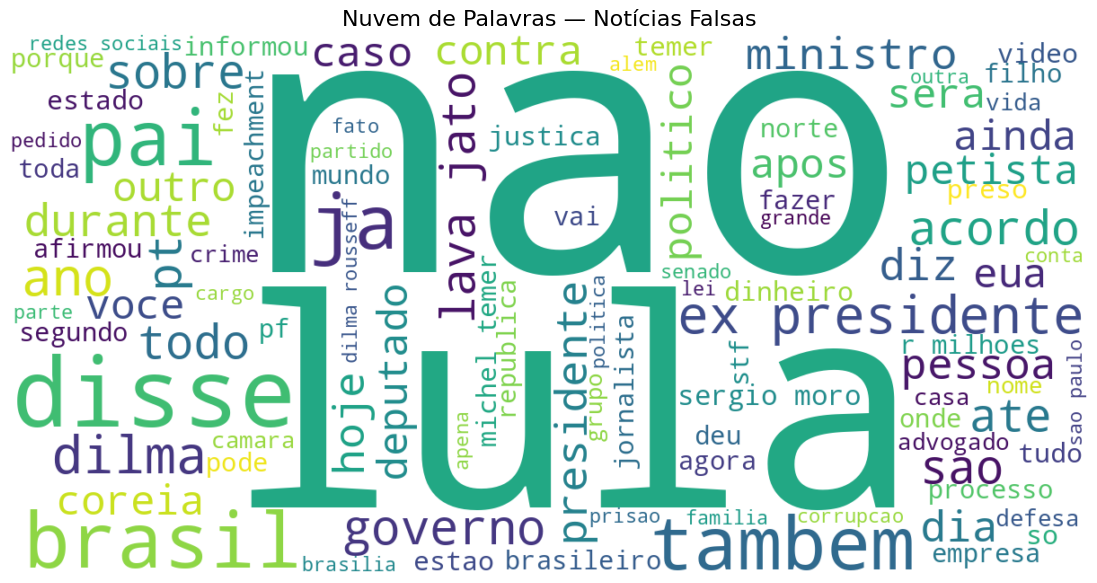

In [60]:
textos_falsos = " ".join(
    df.loc[
        df["label"] == "falso",
        "texto_preprocessado_sem_acento"
    ]
)

nuvem_falsos = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(stopwords_pt),
    max_words=100
).generate(textos_falsos)

plt.figure(figsize=(14, 7))
plt.imshow(nuvem_falsos, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Nuvem de Palavras — Notícias Falsas",
    fontsize=16
)
plt.show()

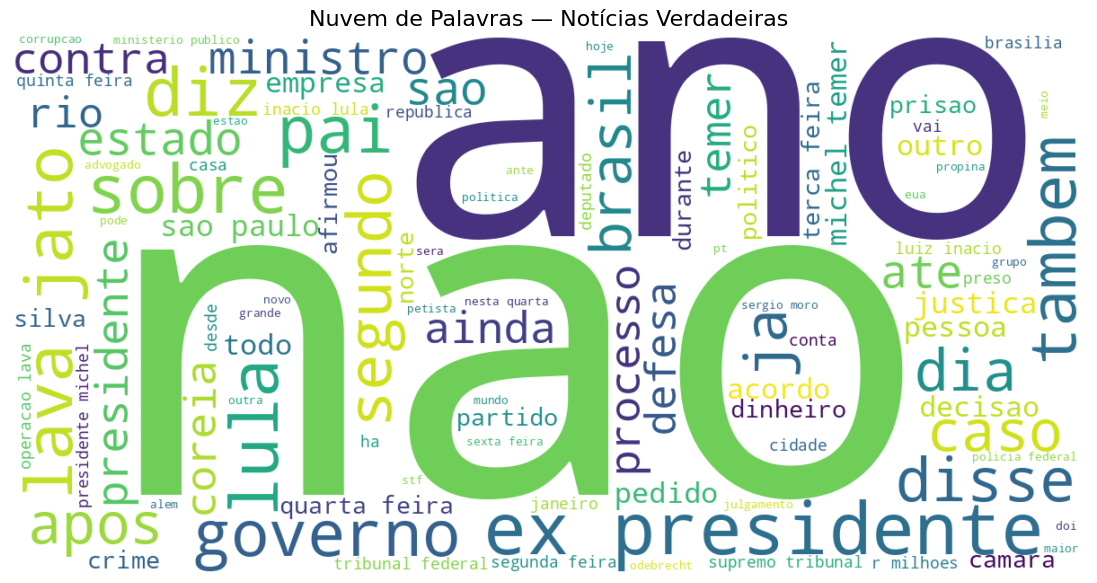

In [61]:
textos_verdadeiros = " ".join(
    df.loc[
        df["label"] == "verdadeiro",
        "texto_preprocessado_sem_acento"
    ]
)

nuvem_verdadeiros = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(stopwords_pt),
    max_words=100
).generate(textos_verdadeiros)

plt.figure(figsize=(14, 7))
plt.imshow(nuvem_verdadeiros, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Nuvem de Palavras — Notícias Verdadeiras",
    fontsize=16
)
plt.show()